# Source vs Target Domain FlowPic Visualization

This notebook visualizes flowpics from source and target domains to understand domain shift.

In [34]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

from data_utils.csv_dataloader import CSVFlowPicDataset

%matplotlib inline

## Configuration

In [35]:
# Define source and target weeks
DATASET_ROOT = Path('/home/anatbr/dataset/CESNET-TLS-Year22')
SOURCE_WEEK = 'WEEK-2022-33'
TARGET_WEEK = 'WEEK-2022-40'

# Parameters
RESOLUTION = 256
MAX_DT_MS = 4000  # Maximum delta time in milliseconds
NUM_SAMPLES_PER_CLASS = 5  # Number of random samples to show per class
DATA_SAMPLE_FRAC = 0.001  # Sample 10% of data for faster loading
SEED = 42

# Load label mapping
label_mapping_path = DATASET_ROOT / 'label_mapping.json'
with open(label_mapping_path, 'r') as f:
    label_mapping_raw = json.load(f)

# Create label indices mapping (same as in train_per_week_cesnet.py)
app_names = sorted(label_mapping_raw.keys())
label_mapping = {app_name: i for i, app_name in enumerate(app_names)}
reverse_label_mapping = {i: app_name for app_name, i in label_mapping.items()}

print(f"Number of classes: {len(label_mapping)}")
print(f"\nClasses: {list(label_mapping.keys())}")

Number of classes: 180

Classes: ['3dsecure', 'accuweather', 'adobe-ads', 'adobe-analytics', 'adobe-authentication', 'adobe-cloud', 'adobe-notifications', 'adobe-search', 'adobe-updater', 'airbank-ib', 'alza-bnr', 'alza-cdn', 'alza-logapi', 'alza-webapi', 'amazon-advertising', 'amazon-alexa', 'amazon-prime', 'apple-icloud', 'apple-itunes', 'apple-location', 'apple-ocsp', 'apple-pancake', 'apple-siri', 'apple-updates', 'apple-weather', 'appnexus', 'aukro-backend', 'autodesk', 'avast', 'bing', 'bitdefender-gravityzone', 'bitdefender-nimbus', 'booking-com', 'cesnet-filesender', 'cesnet-gerrit', 'cesnet-kalendar', 'cesnet-login', 'cesnet-nerd', 'cesnet-perun', 'chmi', 'chrome-remotedesktop', 'ctu-felmail', 'ctu-idp2', 'ctu-kos', 'ctu-kosapi', 'ctu-matrix', 'datova-schranka', 'discord', 'docker-authentication', 'docker-registry', 'doh', 'dopravni-info', 'dropbox', 'duckduckgo', 'ea-games', 'edge-ntp', 'eset-edf', 'eset-edtd', 'eset-epns', 'eset-esa', 'eset-ts', 'facebook-graph', 'facebook-m

## Load Datasets

In [48]:
df = pd.read_parquet(source_train_path)

In [54]:
df.iloc[1111]

ID                                                               332255833
SRC_IP                                                     125.119.103.239
DST_IP                                                          2.16.2.112
DST_ASN                                                              20940
DST_PORT                                                               443
PROTOCOL                                                                 6
TLS_SNI                                              play.itunes.apple.com
TLS_JA3                                   773906b0efdefa24a7f2b8eb6985bf37
TIME_FIRST                                             2022-08-14T22:00:00
TIME_LAST                                       2022-08-14T22:00:20.108862
DURATION                                                         20.108862
BYTES                                                                 4306
BYTES_REV                                                             8798
PACKETS                  

In [36]:
# Load source domain data
source_train_path = DATASET_ROOT / SOURCE_WEEK / 'train.parquet'
print(f"Loading source domain from: {source_train_path}")
source_dataset = CSVFlowPicDataset(
    csv_paths=[source_train_path],
    resolution=RESOLUTION,
    max_dt_ms=MAX_DT_MS,
    label_mapping=label_mapping,
    verbose=True,
    data_sample_frac=DATA_SAMPLE_FRAC,
    seed=SEED,
    dataset_format='cesnet_parquet',
    log_t_axis=False
)

# Load target domain data
target_train_path = DATASET_ROOT / TARGET_WEEK / 'train.parquet'
print(f"\nLoading target domain from: {target_train_path}")
target_dataset = CSVFlowPicDataset(
    csv_paths=[target_train_path],
    resolution=RESOLUTION,
    max_dt_ms=MAX_DT_MS,
    label_mapping=label_mapping,
    verbose=True,
    data_sample_frac=DATA_SAMPLE_FRAC,
    seed=SEED,
    dataset_format='cesnet_parquet',
    log_t_axis=False
)

print(f"\nSource dataset size: {len(source_dataset)}")
print(f"Target dataset size: {len(target_dataset)}")

Loading source domain from: /home/anatbr/dataset/CESNET-TLS-Year22/WEEK-2022-33/train.parquet


Loading files: 100%|██████████| 1/1 [00:11<00:00, 11.45s/it, total_samples=4893]



Loading target domain from: /home/anatbr/dataset/CESNET-TLS-Year22/WEEK-2022-40/train.parquet


Loading files: 100%|██████████| 1/1 [00:16<00:00, 16.60s/it, total_samples=7219]


Source dataset size: 4893
Target dataset size: 7219


## Organize Samples by Class

In [37]:
def organize_samples_by_class(dataset, num_samples=5):
    """Organize dataset samples by class label."""
    samples_by_class = defaultdict(list)
    
    for i in tqdm(range(len(dataset)), desc="Organizing samples"):
        flowpic, label = dataset[i]
        
        if len(samples_by_class[label]) < num_samples:
            samples_by_class[label.item()].append(flowpic.numpy())
        
        # Stop if we have enough samples for all classes
        if all(len(samples) >= num_samples for samples in samples_by_class.values() if len(samples) > 0):
            if len(samples_by_class) >= len(label_mapping):
                break
    
    return dict(samples_by_class)

print("Organizing source domain samples...")
source_samples = organize_samples_by_class(source_dataset, NUM_SAMPLES_PER_CLASS)

print("Organizing target domain samples...")
target_samples = organize_samples_by_class(target_dataset, NUM_SAMPLES_PER_CLASS)

print(f"\nSource classes found: {len(source_samples)}")
print(f"Target classes found: {len(target_samples)}")

Organizing source domain samples...


Organizing samples: 100%|██████████| 4893/4893 [00:02<00:00, 2132.97it/s]


Organizing target domain samples...


Organizing samples: 100%|██████████| 7219/7219 [00:03<00:00, 2136.46it/s]


Source classes found: 5063
Target classes found: 7391


## Compute Mean FlowPics per Class

In [38]:
def compute_mean_flowpics(dataset):
    """Compute mean flowpic for each class."""
    flowpics_by_class = defaultdict(list)
    
    for i in tqdm(range(len(dataset)), desc="Computing means"):
        flowpic, label = dataset[i]
        flowpics_by_class[label.item()].append(flowpic.numpy())
    
    mean_flowpics = {}
    for label, flowpics in flowpics_by_class.items():
        mean_flowpics[label] = np.mean(flowpics, axis=0)
    
    return mean_flowpics

print("Computing source domain mean flowpics...")
source_means = compute_mean_flowpics(source_dataset)

print("Computing target domain mean flowpics...")
target_means = compute_mean_flowpics(target_dataset)

print(f"\nMean flowpics computed for {len(source_means)} source classes")
print(f"Mean flowpics computed for {len(target_means)} target classes")

Computing source domain mean flowpics...


Computing means: 100%|██████████| 4893/4893 [00:02<00:00, 2235.82it/s]


Computing target domain mean flowpics...


Computing means: 100%|██████████| 7219/7219 [00:03<00:00, 2172.78it/s]



Mean flowpics computed for 170 source classes
Mean flowpics computed for 172 target classes


## Visualization: Random Samples per Class

Classes present in both domains: 167



/tmp/ipykernel_1899505/1887152004.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


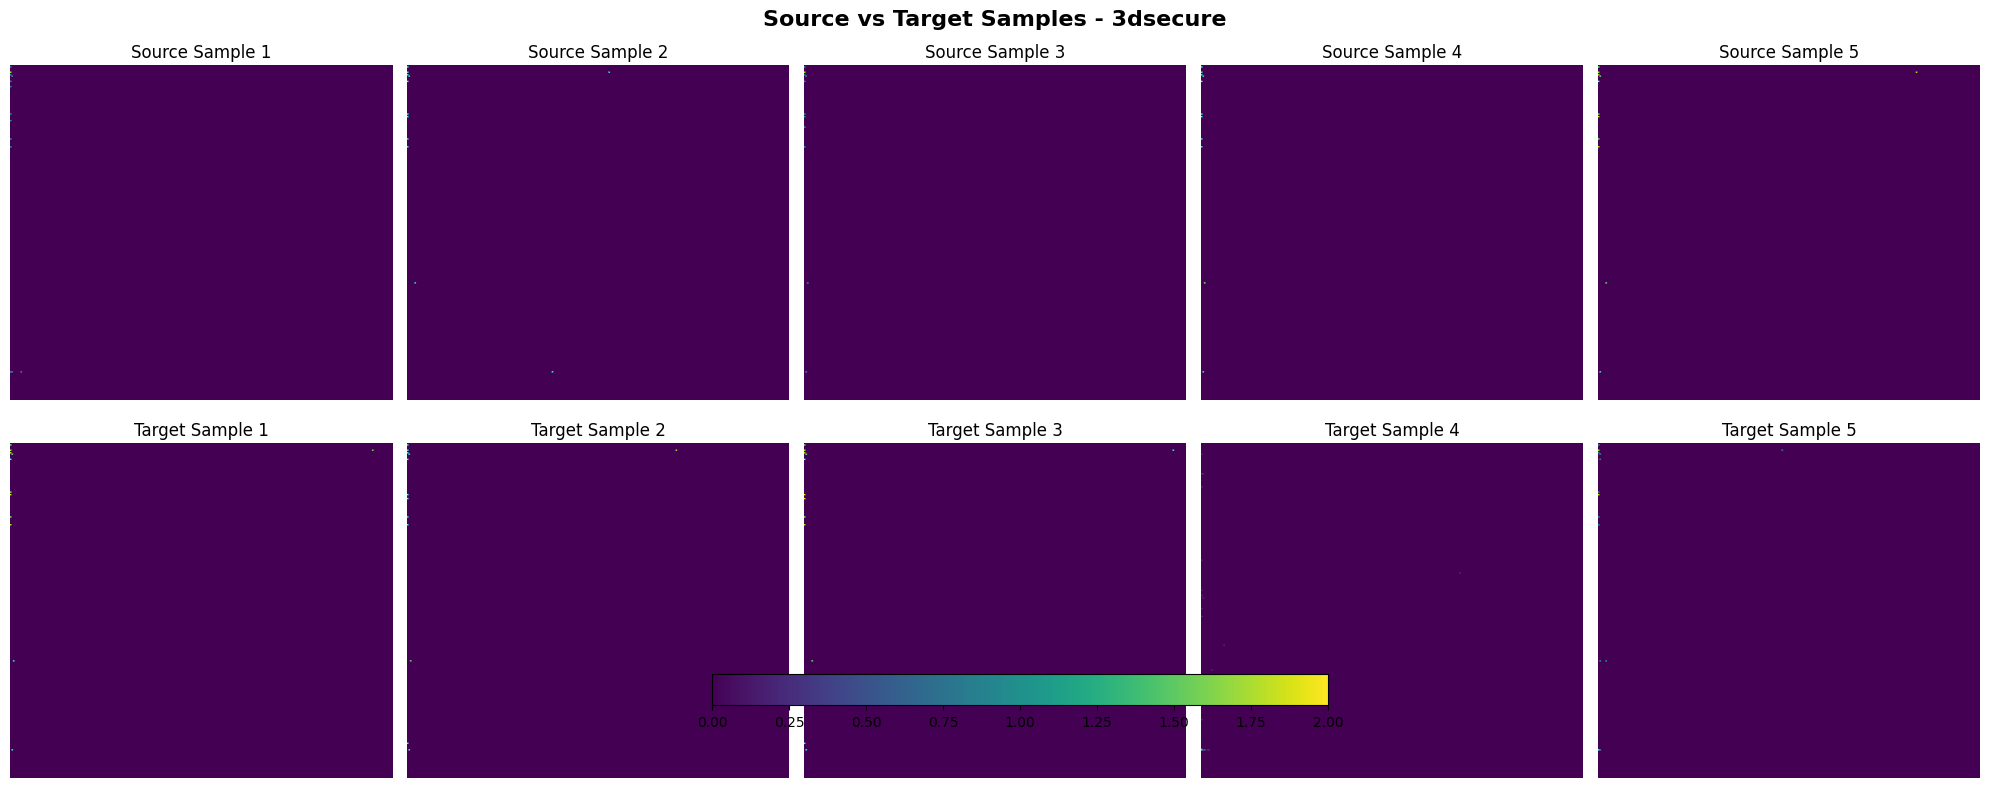

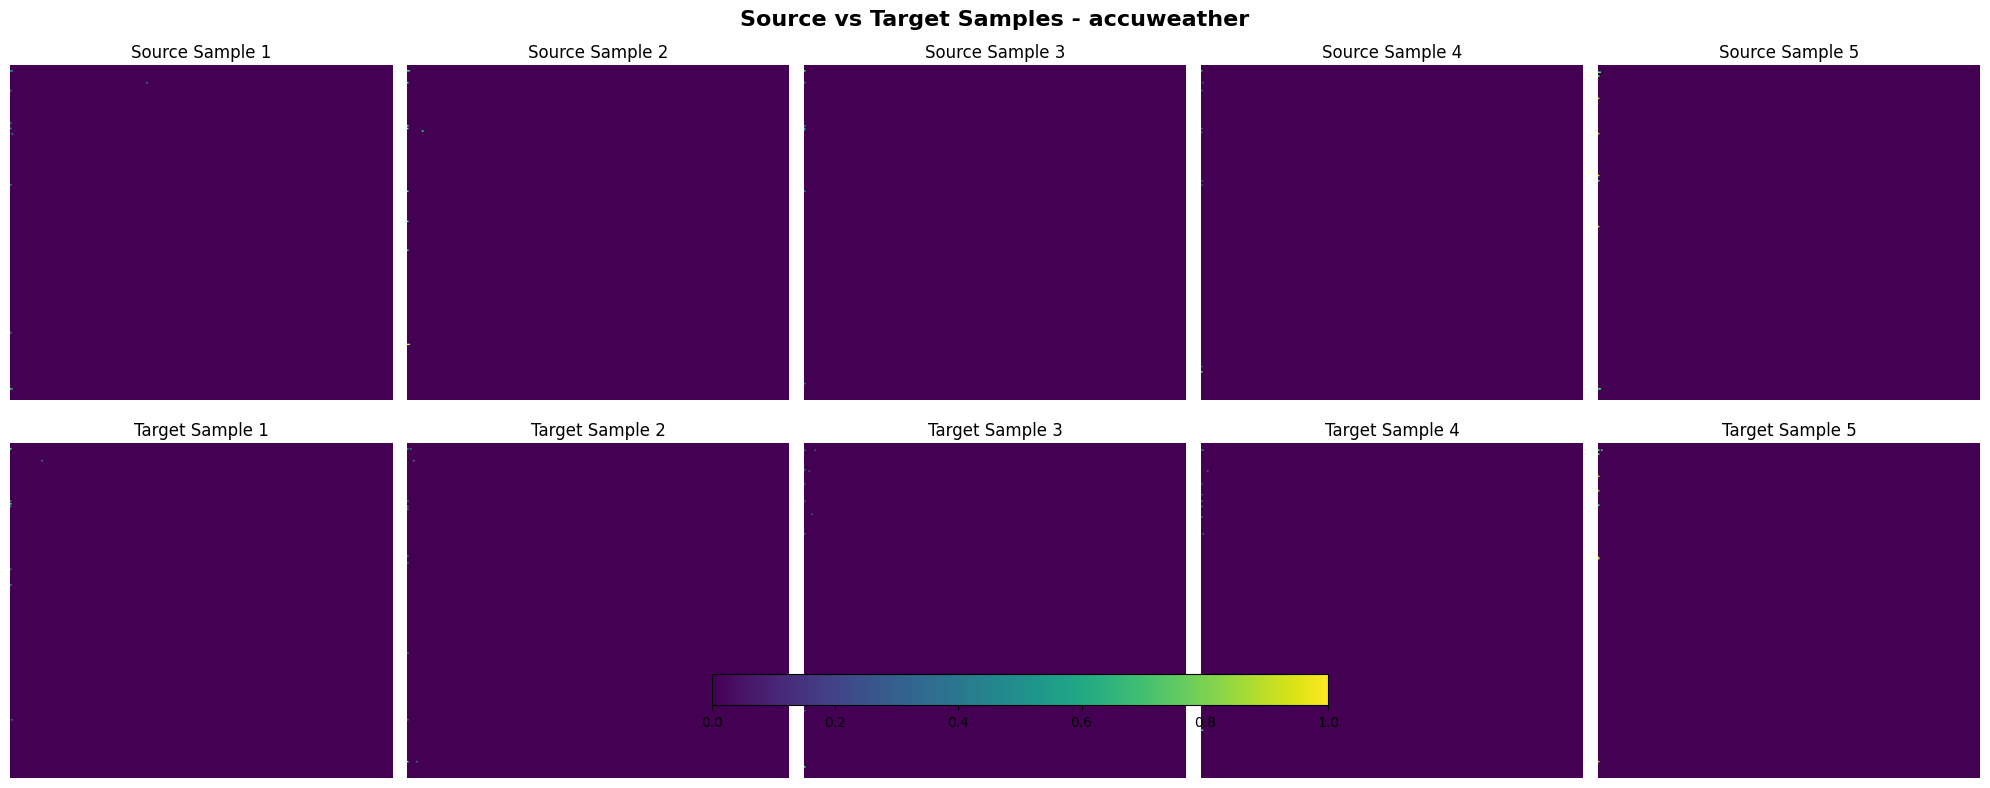

In [39]:
def plot_samples_comparison(source_samples, target_samples, class_label, num_samples=5):
    """Plot source vs target samples for a given class."""
    class_name = reverse_label_mapping.get(class_label, f"Class {class_label}")
    
    fig, axes = plt.subplots(2, num_samples, figsize=(20, 8))
    fig.suptitle(f'Source vs Target Samples - {class_name}', fontsize=16, fontweight='bold')
    
    # Plot source samples
    source_fps = source_samples.get(class_label, [])
    for i in range(num_samples):
        ax = axes[0, i]
        if i < len(source_fps):
            im = ax.imshow(source_fps[i].squeeze(), cmap='viridis', aspect='auto')
            ax.set_title(f'Source Sample {i+1}')
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Source Sample {i+1}')
        ax.axis('off')
    
    # Plot target samples
    target_fps = target_samples.get(class_label, [])
    for i in range(num_samples):
        ax = axes[1, i]
        if i < len(target_fps):
            im = ax.imshow(target_fps[i].squeeze(), cmap='viridis', aspect='auto')
            ax.set_title(f'Target Sample {i+1}')
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Target Sample {i+1}')
        ax.axis('off')
    
    # Add colorbar
    fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', pad=0.05, fraction=0.05)
    
    plt.tight_layout()
    plt.show()

# Plot for all classes that have samples in both domains
common_classes = set(source_samples.keys()) & set(target_samples.keys())
print(f"Classes present in both domains: {len(common_classes)}\n")

for class_label in sorted(common_classes)[:2]:
    plot_samples_comparison(source_samples, target_samples, class_label, NUM_SAMPLES_PER_CLASS)

## Visualization: Mean FlowPics Comparison

In [41]:
def plot_mean_flowpics_comparison(source_means, target_means, max_classes_per_plot=5):
    """Plot mean flowpics for source vs target for all classes."""
    common_classes = sorted(set(source_means.keys()) & set(target_means.keys()))
    num_classes = len(common_classes)
    
    if num_classes == 0:
        print("No common classes found!")
        return
    
    # Split into multiple figures if there are too many classes
    num_plots = (num_classes + max_classes_per_plot - 1) // max_classes_per_plot
    
    for plot_idx in range(num_plots):
        start_idx = plot_idx * max_classes_per_plot
        end_idx = min(start_idx + max_classes_per_plot, num_classes)
        classes_to_plot = common_classes[start_idx:end_idx]
        
        # Create grid of subplots
        cols = 3  # Source, Target, Difference
        rows = len(classes_to_plot)
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
        if rows == 1:
            axes = axes.reshape(1, -1)
        
        fig.suptitle(f'Mean FlowPics: {SOURCE_WEEK} (Source) vs {TARGET_WEEK} (Target) - Part {plot_idx + 1}/{num_plots}', 
                     fontsize=16, fontweight='bold')
        
        for idx, class_label in enumerate(classes_to_plot):
            class_name = reverse_label_mapping.get(class_label, f"Class {class_label}")
            
            source_mean = source_means[class_label].squeeze()
            target_mean = target_means[class_label].squeeze()
            difference = target_mean - source_mean
            
            # Find common vmin/vmax for source and target
            vmin = min(source_mean.min(), target_mean.min())
            vmax = max(source_mean.max(), target_mean.max())
            
            # Plot source mean
            im1 = axes[idx, 0].imshow(source_mean, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
            axes[idx, 0].set_title(f'{class_name}\nSource Mean')
            axes[idx, 0].axis('off')
            plt.colorbar(im1, ax=axes[idx, 0], fraction=0.046)
            
            # Plot target mean
            im2 = axes[idx, 1].imshow(target_mean, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
            axes[idx, 1].set_title(f'{class_name}\nTarget Mean')
            axes[idx, 1].axis('off')
            plt.colorbar(im2, ax=axes[idx, 1], fraction=0.046)
            
            # Plot difference
            im3 = axes[idx, 2].imshow(difference, cmap='RdBu_r', aspect='auto', 
                                       vmin=-abs(difference).max(), vmax=abs(difference).max())
            axes[idx, 2].set_title(f'{class_name}\nDifference (Target - Source)')
            axes[idx, 2].axis('off')
            plt.colorbar(im3, ax=axes[idx, 2], fraction=0.046)
        
        plt.tight_layout()
        plt.show()

print(f"Plotting mean flowpics (will split into multiple figures if needed)...")
plot_mean_flowpics_comparison(source_means, target_means, max_classes_per_plot=5)

Plotting mean flowpics (will split into multiple figures if needed)...


KeyboardInterrupt: 

In [ ]:
## Time Axis Analysis: Largest Non-Zero X Index

def get_max_nonzero_x_indices(dataset, dataset_name="Dataset"):
    """Extract the largest non-zero x index (time axis) for each flowpic."""
    max_x_indices = []
    class_labels = []
    
    for i in tqdm(range(len(dataset)), desc=f"Analyzing {dataset_name}"):
        flowpic, label = dataset[i]
        flowpic_np = flowpic.numpy().squeeze()
        
        # Find all non-zero positions
        nonzero_positions = np.argwhere(flowpic_np > 0)
        
        if len(nonzero_positions) > 0:
            # Get the maximum x index (column index - time axis)
            max_x = nonzero_positions[:, 1].max()
            max_x_indices.append(max_x)
            class_labels.append(label)
        else:
            # If completely empty, record 0
            max_x_indices.append(0)
            class_labels.append(label)
    
    return max_x_indices, class_labels

# Analyze both source and target domains
print("Analyzing source domain...")
source_max_x, source_labels = get_max_nonzero_x_indices(source_dataset, "Source")

print("Analyzing target domain...")
target_max_x, target_labels = get_max_nonzero_x_indices(target_dataset, "Target")

# Create DataFrames
source_df = pd.DataFrame({
    'max_x_index': source_max_x,
    'label': source_labels,
    'class_name': [reverse_label_mapping.get(l, f"Class {l}") for l in source_labels],
    'domain': 'Source'
})

target_df = pd.DataFrame({
    'max_x_index': target_max_x,
    'label': target_labels,
    'class_name': [reverse_label_mapping.get(l, f"Class {l}") for l in target_labels],
    'domain': 'Target'
})

combined_df = pd.concat([source_df, target_df], ignore_index=True)

print(f"\nSource domain max x index stats:")
print(source_df['max_x_index'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))
print(f"\nTarget domain max x index stats:")
print(target_df['max_x_index'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))


Analyzing source domain...


Analyzing Source:   0%|          | 0/4893 [00:00<?, ?it/s]

Analyzing Source: 100%|██████████| 4893/4893 [00:03<00:00, 1343.15it/s]


Analyzing target domain...


Analyzing Target: 100%|██████████| 7219/7219 [00:05<00:00, 1369.64it/s]



Source domain max x index stats:
count    4893.000000
mean       17.051093
std        40.648241
min         0.000000
50%         3.000000
90%        43.000000
95%       107.000000
99%       223.000000
max       255.000000
Name: max_x_index, dtype: float64

Target domain max x index stats:
count    7219.000000
mean       20.105416
std        43.463767
min         0.000000
50%         4.000000
90%        59.000000
95%       125.000000
99%       219.820000
max       255.000000
Name: max_x_index, dtype: float64


## Statistical Analysis of Domain Shift

In [46]:
def compute_domain_shift_metrics(source_means, target_means):
    """Compute metrics quantifying domain shift."""
    common_classes = set(source_means.keys()) & set(target_means.keys())
    
    results = []
    for class_label in sorted(common_classes):
        class_name = reverse_label_mapping.get(class_label, f"Class {class_label}")
        
        source_mean = source_means[class_label].squeeze()
        target_mean = target_means[class_label].squeeze()
        
        # Compute metrics
        mse = np.mean((source_mean - target_mean) ** 2)
        mae = np.mean(np.abs(source_mean - target_mean))
        max_diff = np.max(np.abs(source_mean - target_mean))
        
        # Correlation
        correlation = np.corrcoef(source_mean.flatten(), target_mean.flatten())[0, 1]
        
        results.append({
            'Class': class_name,
            'Label': class_label,
            'MSE': mse,
            'MAE': mae,
            'Max Diff': max_diff,
            'Correlation': correlation
        })
    
    return pd.DataFrame(results)

shift_metrics = compute_domain_shift_metrics(source_means, target_means)
print("\nDomain Shift Metrics:")
print("=" * 80)
print(shift_metrics.to_string(index=False))
print("\n" + "=" * 80)
print("\nSummary Statistics:")
print(shift_metrics[['MSE', 'MAE', 'Max Diff', 'Correlation']].describe())


Domain Shift Metrics:
                   Class  Label      MSE      MAE  Max Diff  Correlation
                3dsecure      0 0.000059 0.000159  0.925000     0.796167
             accuweather      1 0.000036 0.000191  0.534314     0.690729
               adobe-ads      2 0.000081 0.000258  0.937500     0.506554
         adobe-analytics      3 0.000066 0.000178  0.666667     0.622654
    adobe-authentication      4 0.000066 0.000135  1.000000     0.762728
             adobe-cloud      5 0.000137 0.000367  1.444444     0.556103
     adobe-notifications      6 0.000051 0.000193  0.666667     0.722399
           adobe-updater      8 0.000634 0.000475  4.933333     0.496672
              airbank-ib      9 0.000307 0.000432  2.000000     0.603785
                alza-bnr     10 0.000053 0.000159  0.600000     0.718311
                alza-cdn     11 0.000561 0.000380  4.000000     0.545442
             alza-logapi     12 0.000117 0.000257  1.802198     0.698452
             alza-webapi    

## Per-Class Distribution Comparison

In [ ]:
def plot_class_distributions(source_dataset, target_dataset, label_mapping):
    """Plot class distributions for source and target domains."""
    source_labels = [label for _, label in source_dataset]
    target_labels = [label for _, label in target_dataset]
    
    source_counts = pd.Series(source_labels).value_counts().sort_index()
    target_counts = pd.Series(target_labels).value_counts().sort_index()
    
    # Create comparison dataframe
    comparison = pd.DataFrame({
        'Source': source_counts,
        'Target': target_counts
    }).fillna(0)
    
    # Add class names
    comparison['Class'] = comparison.index.map(lambda x: reverse_label_mapping.get(x, f"Class {x}"))
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar plot
    comparison[['Source', 'Target']].plot(kind='bar', ax=axes[0])
    axes[0].set_title('Class Distribution Comparison', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Class Label')
    axes[0].set_ylabel('Number of Samples')
    axes[0].legend(['Source', 'Target'])
    axes[0].grid(axis='y', alpha=0.3)
    
    # Relative difference
    comparison['Relative_Diff'] = (comparison['Target'] - comparison['Source']) / (comparison['Source'] + 1e-6)
    comparison['Relative_Diff'].plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Relative Distribution Shift', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Class Label')
    axes[1].set_ylabel('(Target - Source) / Source')
    axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return comparison

distribution_comparison = plot_class_distributions(source_dataset, target_dataset, label_mapping)
print("\nClass Distribution Comparison:")
print(distribution_comparison)

## Save Visualizations

In [ ]:
# Save metrics to CSV
output_dir = Path('visualizations')
output_dir.mkdir(exist_ok=True)

shift_metrics.to_csv(output_dir / f'domain_shift_metrics_{SOURCE_WEEK}_to_{TARGET_WEEK}.csv', index=False)
distribution_comparison.to_csv(output_dir / f'distribution_comparison_{SOURCE_WEEK}_to_{TARGET_WEEK}.csv')

print(f"\nMetrics saved to {output_dir}/")